In [11]:

%matplotlib inline
%load_ext autoreload
%autoreload 
import os
from nuimages import NuImages

nuim = NuImages(dataroot='/app/workdir/dataset', version='v1.0-train', verbose=True, lazy=True)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading nuImages tables for version v1.0-train...
Done loading in 0.000 seconds (lazy=True).


In [ ]:
!python3 download_ing.py --data_dir='/app/workdir/dataset' --version='v1.0-train' --size=200 


2025-04-29 21:37:39.047684: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-29 21:37:39.047723: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-29 21:37:39.048842: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Loading nuImages tables for version v1.0-test...
Done loading in 0.000 seconds (lazy=True).
Loaded 126276 sample_data(s) in 3.544s,
Loaded 346 calibrated_sensor(s) in 0.045s,
Loaded 6 sensor(s) in 0.000s,
2025-04-29 21:37:45,366 INFO      200 images to process. Be patient, this will take a long time.
2025-04-29 21:37:46,133	WARNING services.py:2070 -- WARNING: Th

In [13]:
len(os.listdir('/app/workdir/dataset/CAM_FRONT_processed')) 

200

In [ ]:
from utils import get_dataset, parse_tfrecord_fn
from object_detection.utils import visualization_utils as viz_utils
from object_detection.utils.label_map_util import create_category_index_from_labelmap
import matplotlib.pyplot as plt


In [28]:
dataset = get_dataset('/app/workdir/dataset/CAM_FRONT_processed/*.tfrecord')
label_map_path = '/app/workdir/label_map.pbtxt'
category_index = create_category_index_from_labelmap(label_map_path, use_display_name=True)


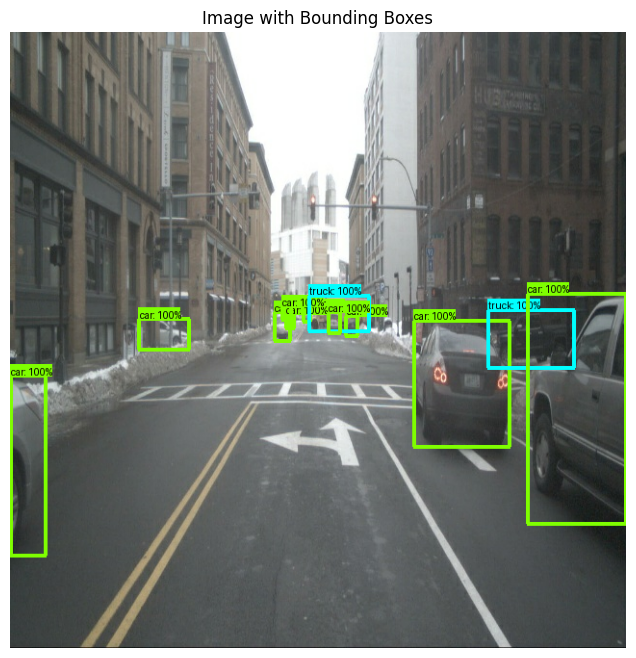

In [39]:
dataset = dataset.shuffle(buffer_size=10)
for raw_record in dataset.take(1):
    image_tensor, boxes_tensor, labels_tensor = parse_tfrecord_fn(raw_record)

    image_np = image_tensor.numpy().copy()
    boxes_np = boxes_tensor.numpy()
    labels_np = labels_tensor.numpy()

    viz_utils.visualize_boxes_and_labels_on_image_array(
        image_np,
        boxes_np,
        labels_np,
        [1.0] * len(labels_np), # detection scores
        category_index=category_index,
        use_normalized_coordinates=False,
        max_boxes_to_draw=50,
        # min_score_thresh=0.5
    )

    plt.figure(figsize=(12, 8))
    plt.imshow(image_np)
    plt.axis('off')
    plt.title("Image with Bounding Boxes")
    plt.show()

In [12]:
len(os.listdir('samples/CAM_FRONT'))

18368

In [31]:
boxes_tensor

<tf.Tensor: shape=(0, 4), dtype=float32, numpy=array([], shape=(0, 4), dtype=float32)>